In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [3]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


In [4]:
# =============================================================================
# CONFIGURATION AND PHYSICAL PARAMETERS (KNOWN/PROVIDED)
# =============================================================================


# Known physical parameters (provided by user)
g = 9.81    # gravitational acceleration (m/s²)
L1 = 1.0    # length of first pendulum (m)
L2 = 1.0    # length of second pendulum (m)
M1 = 1.0    # mass of first pendulum (kg)
M2 = 1.0    # mass of second pendulum (kg)


Look at the [link](https://physics.umd.edu/hep/drew/pendulum2.html)

In [5]:
# =============================================================================
# PART 1: SYNTHETIC DATA GENERATION (ONLY x₂)
# =============================================================================

def double_pendulum_ode(t, state):
    """
    Double pendulum equations of motion (ODEs).
    
    State vector: [theta1, omega1, theta2, omega2]
    """
    theta1, omega1, theta2, omega2 = state
    delta = theta2 - theta1
    
    cos_delta = np.cos(delta)
    sin_delta = np.sin(delta)
    
    # Denominator terms
    den1 = (M1 + M2) * L1 - M2 * L1 * cos_delta**2
    den2 = (L2 / L1) * den1
    
    # Angular accelerations from Lagrangian mechanics
    domega1 = (
        M2 * L1 * omega1**2 * sin_delta * cos_delta +
        M2 * g * np.sin(theta2) * cos_delta +
        M2 * L2 * omega2**2 * sin_delta -
        (M1 + M2) * g * np.sin(theta1)
    ) / den1
    
    domega2 = (
        -M2 * L2 * omega2**2 * sin_delta * cos_delta +
        (M1 + M2) * g * np.sin(theta1) * cos_delta -
        (M1 + M2) * L1 * omega1**2 * sin_delta -
        (M1 + M2) * g * np.sin(theta2)
    ) / den2
    
    return [omega1, domega1, omega2, domega2]


def generate_x2_dataset(t_max=3.0, n_points=300, initial_conditions=None, noise_std=0.0):
    """
    Generate synthetic dataset containing ONLY x₂ coordinate.
    
    x₂ = L1*sin(θ₁) + L2*sin(θ₂)  (horizontal position of second mass)
    
    Returns:
        dict with 't', 'x2', and 'initial_conditions'
        Also returns full solution for validation (not used in training)
    """
    if initial_conditions is None:
        initial_conditions = [np.pi/3, 0.0, np.pi/2, 0.0]
    
    y0 = initial_conditions
    
    # Numerical integration using RK45
    t_eval = np.linspace(0, t_max, n_points)
    sol = solve_ivp(
        double_pendulum_ode,
        [0, t_max],
        y0,
        t_eval=t_eval,
        method='RK45',
        rtol=1e-10,
        atol=1e-12
    )
    
    t = sol.t
    theta1 = sol.y[0]
    omega1 = sol.y[1]
    theta2 = sol.y[2]
    omega2 = sol.y[3]
    
    # Compute x₂ coordinate (THIS IS THE ONLY TRAINING DATA)
    x2 = L1 * np.sin(theta1) + L2 * np.sin(theta2)
    
    # Add noise if specified
    if noise_std > 0:
        x2 = x2 + np.random.normal(0, noise_std, size=x2.shape)
    
    # Training dataset (only x2)
    training_data = {
        't': t,
        'x2': x2,
        'initial_conditions': initial_conditions
    }
    
    # Full solution for validation (not used in training)
    validation_data = {
        't': t,
        'theta1': theta1, 'omega1': omega1,
        'theta2': theta2, 'omega2': omega2,
        'x1': L1 * np.sin(theta1),
        'x2': x2,
        'y1': -L1 * np.cos(theta1),
        'y2': -L1 * np.cos(theta1) - L2 * np.cos(theta2)
    }
    
    return training_data, validation_data



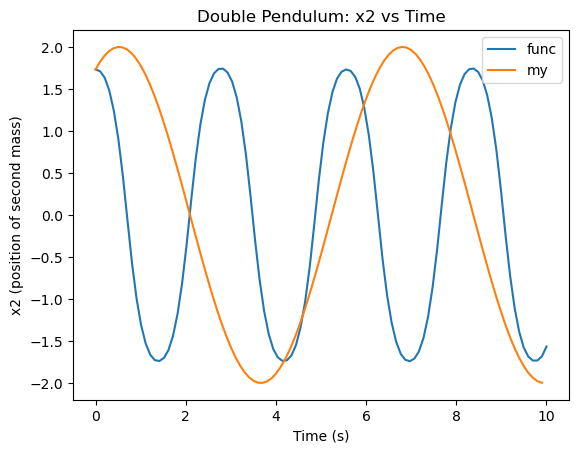

In [23]:
X_train, X_vali = generate_x2_dataset(10, 100, [np.pi/3, 0.0, np.pi/3, 0.0], 0)
T_1 = np.arange(0,10,0.1)
T_2 = np.arange(0,10,0.1)
X = np.sin(T_1+np.pi/3) + np.sin(T_2+np.pi/3)
plt.plot(X_train['t'], X_train['x2'], label="func")
plt.plot( T_1, X, label="my")
plt.xlabel('Time (s)')
plt.ylabel('x2 (position of second mass)')
plt.title('Double Pendulum: x2 vs Time')
plt.legend()
plt.show()